# 2025 DL Lab4: Semantic Segmentation on BCSS

Before we start, please put **your name** and **SID** in following format: <br>
Hi I'm 陸仁賈, 314831000.

**Your Answer:**    
Hi I'm 李朋逸, 314831024.

## Overview

- Semantic segmentation is a computer vision task that aims to classify each pixel in an image into specific objects or regions.

- In this assignment, you will implement a segmentor to classify the specific types of breast cancer lesions.

- The segmentor implemented in this assignment is U-Net, and you are required to construct it from scratch


## Kaggle Competition
Kaggle is an online community of data scientists and machine learning practitioners. Kaggle allows users to find and publish datasets, explore and build models in a web-based data-science environment, work with other data scientists and machine learning engineers, and enter competitions to solve data science challenges.

This assignment use kaggle to calculate your grade.  
Please use this [**LINK**](https://www.kaggle.com/t/722cdf813c894c5ba56591628d7975db) to join the competition.

## Unzip Data

Unzip BCSS.zip

+ `train` : Contains all training images
+ `val` : Contains all validation images
+ `test` : Contains all test images
+ `train_mask` : Contains all masks for the training set
+ `val_mask` : Contains all masks for the validation set

The train set contains 26,760 images, the val set contains 5,429 images, and the test set contains 4,000 images.

# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import torchvision
import torch.nn.functional as F
from torch.autograd import Variable

from PIL import Image
import cv2
import albumentations as A

import time
import os
from tqdm.notebook import tqdm
import torchvision.models as models
from torch.nn import TransformerEncoder, TransformerEncoderLayer # 需要這兩個

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Preprocessing

#### Verify that the paths to the image and mask are correct, and plot the position of the mask on the image.

First, the code establishes DataFrames for the paths of training and validation images, including their corresponding mask paths.

Second, it presents the total number of images in both the training and validation sets.

Third, the code loads a sample training image and its associated mask, visually demonstrating the image and the applied mask in a graphical representation.

In [3]:
TRAIN_IMAGE_PATH = './BCSS/train/'
VAL_IMAGE_PATH = './BCSS/val/'
TRAIN_MASK_PATH = './BCSS/train_mask/'
VAL_MASK_PATH = './BCSS/val_mask/'

In [4]:
n_classes = 3

def create_df(IMAGE_PATH):
    name = []
    for dirname, _, filenames in os.walk(IMAGE_PATH):
        for filename in filenames:
            name.append(filename.split('.')[0])

    return pd.DataFrame({'id': name}, index = np.arange(0, len(name)))

train_df = create_df(TRAIN_IMAGE_PATH)
val_df = create_df(VAL_IMAGE_PATH)


print('Total Train Images: ', len(train_df))
print('Total Val Images: ', len(val_df))

Total Train Images:  26760
Total Val Images:  5429


In [5]:
X_train = train_df['id'].to_numpy()
X_val = val_df['id'].to_numpy()

Image Size (224, 224, 3)
Mask Size (224, 224)


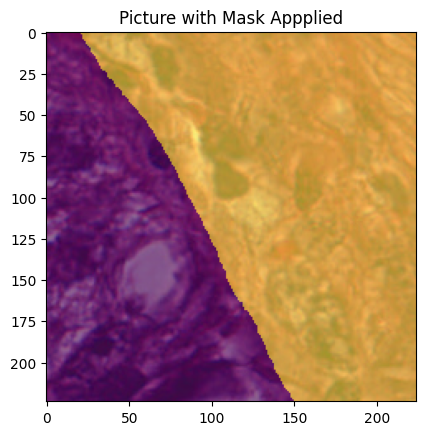

In [22]:
img = Image.open(TRAIN_IMAGE_PATH + train_df['id'][100] + '.png')
mask = Image.open(TRAIN_MASK_PATH + train_df['id'][100] + '.png')
print('Image Size', np.asarray(img).shape)
print('Mask Size', np.asarray(mask).shape)


plt.imshow(img)
plt.imshow(mask, alpha=0.6)
plt.title('Picture with Mask Appplied')
plt.show()

# Loading the Dataset

Define the BCSSDataset for loading the dataset, where each sample comprises an image and its corresponding mask

Build a classs inherit `torch.utils.data.Dataset`.
  
Implement `__init__`, `__getitem__` and `__len__` 3 functions.  

Some operations could be there: setting location of dataset, the method of reading data, label of dataset or transform of dataset.

See [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) for more details

In [6]:
class BCSSDataset(Dataset):
    def __init__(self, img_path, mask_path, X, transform=None):
        self.img_path = img_path
        self.mask_path = mask_path
        self.X = X
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img_fp = os.path.join(self.img_path, self.X[idx] + ".png")
        mask_fp = os.path.join(self.mask_path, self.X[idx] + ".png")

        img = cv2.imread(img_fp)
        if img is None:
            raise FileNotFoundError(f"Image not found: {img_fp}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_fp, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {mask_fp}")

        if self.transform is not None:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]              # 已是 torch.FloatTensor (C,H,W)，且已 Normalize
            mask = aug["mask"]              # 可能是 np.ndarray 或 Tensor（取決於 ToTensorV2）
        else:
            # 若沒 transform，就手動轉成 tensor（不做 normalize）
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0

        # 保證 mask 是 LongTensor（分類 label）
        if isinstance(mask, torch.Tensor):
            mask = mask.long()
        else:
            mask = torch.from_numpy(mask).long()

        return img, mask


## Data augmentation

Data augmentation are techniques used to increase the amount of data by adding slightly modified copies of already existing data or newly created synthetic data from existing data.

PyTorch use `torchvision.transforms` to do data augmentation.
[You can see all function here.](https://pytorch.org/vision/stable/transforms.html)

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2 # albumentations 會用到

mean = [0.723504900932312, 0.5135008096694946, 0.6964303851127625]
std = [0.19520525634288788, 0.24144354462623596, 0.16771525144577026]

transforms_train = A.Compose([
    A.RandomResizedCrop(size = (224,224), scale=(0.8, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5), 
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])


transforms_val = A.Compose([
    A.Resize(height=224, width=224), 
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])

# Dataset

train_set = BCSSDataset(TRAIN_IMAGE_PATH, TRAIN_MASK_PATH, X_train, transforms_train)
val_set = BCSSDataset(VAL_IMAGE_PATH, VAL_MASK_PATH, X_val, transforms_val)

# DataLoader

batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=1, shuffle=False)



In [25]:
train_set[0]

(tensor([[[ 0.8740,  0.3718,  0.2512,  ...,  1.2356,  1.1553,  0.7736],
          [ 1.1151,  0.6329,  0.3115,  ...,  1.1352,  1.1954,  0.9142],
          [ 1.1754,  0.7937,  0.3115,  ...,  1.0749,  1.2557,  0.9343],
          ...,
          [ 1.0347,  1.0749,  1.0146,  ..., -1.3760, -1.6171, -1.7577],
          [ 0.9745,  1.1553,  1.1151,  ..., -1.2756, -1.5568, -1.6372],
          [ 0.8539,  1.1151,  1.1553,  ..., -1.1148, -1.4564, -1.4162]],
 
         [[ 1.3653,  0.7806,  0.7481,  ...,  1.6576,  1.3003,  0.8455],
          [ 1.7226,  0.9917,  0.7806,  ...,  1.6901,  1.3815,  0.9917],
          [ 1.8201,  1.1054,  0.7968,  ...,  1.7551,  1.4465,  1.0892],
          ...,
          [ 1.6901,  1.6576,  1.6901,  ..., -0.4376, -0.5351, -0.6812],
          [ 1.6414,  1.6089,  1.6739,  ..., -0.4701, -0.5513, -0.6325],
          [ 1.5764,  1.5764,  1.6901,  ..., -0.4214, -0.5351, -0.5513]],
 
         [[ 1.3424,  1.2255,  1.0150,  ...,  1.5996,  1.6230,  1.3658],
          [ 1.6697,  1.5061,

# U-net

U-net is a fully convolution neural network for image semantic segmentation. Consist of encoder and decoder parts connected with skip connections. Encoder extract features of different spatial resolution (skip connections) which are used by decoder to define accurate segmentation mask. Use concatenation for fusing decoder blocks with skip connections.


![image](https://hackmd.io/_uploads/rJXtsY_Up.png)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.nn import TransformerEncoder, TransformerEncoderLayer
import numpy as np

class Bottleneck(nn.Module):
    expansion = 4 

    def __init__(self, inplanes, planes, stride=1, downsample=None, norm_layer=nn.BatchNorm2d):
        super(Bottleneck, self).__init__()
        # 1x1 conv
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = norm_layer(planes)
        # 3x3 conv (可能帶 stride)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = norm_layer(planes)
        # 1x1 conv
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, kernel_size=1, bias=False)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity 
        out = self.relu(out)

        return out

def _make_layer(block, inplanes, planes, blocks, stride=1, norm_layer=nn.BatchNorm2d):
    downsample = None
    if stride != 1 or inplanes != planes * block.expansion:
        downsample = nn.Sequential(
            nn.Conv2d(inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
            norm_layer(planes * block.expansion),
        )

    layers = []
    layers.append(block(inplanes, planes, stride, downsample, norm_layer))
    inplanes = planes * block.expansion 
   
    for _ in range(1, blocks):
        layers.append(block(inplanes, planes, norm_layer=norm_layer))

    return nn.Sequential(*layers)



class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None, use_gn=False):
        super().__init__()
        if mid_channels is None:
            mid_channels = out_channels

        Norm = (lambda c: nn.GroupNorm(8, c)) if use_gn else nn.BatchNorm2d

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            Norm(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            Norm(out_channels),
        )
        # 只有 in_channels == out_channels 才做殘差
        self.use_residual = (in_channels == out_channels)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        y = self.block(x)
        if self.use_residual:
            y = y + x
        return self.act(y)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        """
        Final convolution block

        :param in_channels: number of in channels for conv layer
        :param out_channels: number of out channels for conv layer
        """
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=2048, embed_dim=768): 
        super().__init__()
        f_size = img_size // 32 
        self.num_patches = f_size * f_size
        self.patch_size = (1, 1) 
        self.proj = nn.Conv2d(in_channels=in_channels, out_channels=embed_dim, kernel_size=1, stride=1)
    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

class TransUNet(nn.Module):
    def __init__(self, img_size=224, in_channels=3, n_classes=3,
                 embed_dim=768, transformer_layers=12, transformer_heads=12):
        super(TransUNet, self).__init__()
        self.n_classes = n_classes
        norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer
        self.inplanes = 64 

        self.encoder_conv1 = nn.Conv2d(in_channels, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False)
        self.encoder_bn1 = norm_layer(self.inplanes)
        self.encoder_relu = nn.ReLU(inplace=True)
        self.encoder_maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.encoder_layer1 = _make_layer(Bottleneck, self.inplanes, 64, 3, norm_layer=norm_layer)
        self.inplanes = 64 * Bottleneck.expansion 
        self.encoder_layer2 = _make_layer(Bottleneck, self.inplanes, 128, 4, stride=2, norm_layer=norm_layer)
        self.inplanes = 128 * Bottleneck.expansion
        self.encoder_layer3 = _make_layer(Bottleneck, self.inplanes, 256, 6, stride=2, norm_layer=norm_layer)
        self.inplanes = 256 * Bottleneck.expansion
        self.encoder_layer4 = _make_layer(Bottleneck, self.inplanes, 512, 3, stride=2, norm_layer=norm_layer)
    
        # --- 2. Bottleneck (Transformer) ---
        # PatchEmbed 的 in_channels 需要是 layer4 的輸出 channel 數
        self.patch_embed = PatchEmbed(img_size=img_size, in_channels=2048, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        self.pos_drop = nn.Dropout(p=0.1)

        encoder_layer_tf = TransformerEncoderLayer( # 變數名加後綴 _tf 以免衝突
            d_model=embed_dim, nhead=transformer_heads, dim_feedforward=embed_dim * 4,
            dropout=0.1, activation=F.gelu, batch_first=True, norm_first=True
        )
        self.transformer_encoder = TransformerEncoder(encoder_layer_tf, num_layers=transformer_layers)

        self.decoder_up1 = nn.ConvTranspose2d(embed_dim, 512, kernel_size=2, stride=2) # 768->512
        self.decoder_conv1 = DoubleConv(512 + 1024, 512) # Cat(Up_512 + Skip_1024 from layer3) -> 512

        self.decoder_up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2) # 512->256
        self.decoder_conv2 = DoubleConv(256 + 512, 256) # Cat(Up_256 + Skip_512 from layer2) -> 256

        self.decoder_up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2) # 256->128
        self.decoder_conv3 = DoubleConv(128 + 256, 128) # Cat(Up_128 + Skip_256 from layer1) -> 128

        self.decoder_up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2) # 128->64
        self.decoder_conv4 = DoubleConv(64 + 64, 64) # Cat(Up_64 + Skip_64 from conv1 output) -> 64

        self.final_up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False) # H/2 -> H
        self.final_conv = DoubleConv(64, 64)
        self.outc = OutConv(64, n_classes)
        

    def forward(self, x):
        # --- 1. CNN Encoder & Skip Connections ---
        x_in = x # (B, 3, 224, 224)
        # 初始卷積層
        x_conv1_out = self.encoder_conv1(x_in)       # (B, 64, 112, 112)
        x_bn1_out = self.encoder_bn1(x_conv1_out)
        x_relu_out = self.encoder_relu(x_bn1_out)    # Skip connection for decoder_conv4
        x_pool1_out = self.encoder_maxpool(x_relu_out) # (B, 64, 56, 56)

        # ResNet Layers
        x_skip1 = self.encoder_layer1(x_pool1_out)  # (B, 256, 56, 56)
        x_skip2 = self.encoder_layer2(x_skip1)      # (B, 512, 28, 28)
        x_skip3 = self.encoder_layer3(x_skip2)      # (B, 1024, 14, 14)
        x_enc_out = self.encoder_layer4(x_skip3)    # (B, 2048, 7, 7)

        # --- 2. Transformer Bottleneck ---
        x_patch = self.patch_embed(x_enc_out) # (B, 49, 768)
        x_trans = self.pos_drop(x_patch + self.pos_embed)
        x_trans_out = self.transformer_encoder(x_trans) # (B, 49, 768)

        # --- 3. Decoder ---
        B, N, D = x_trans_out.shape
        F_H = F_W = int(np.sqrt(N)) # 7
        x_dec = x_trans_out.transpose(1, 2).view(B, D, F_H, F_W) # (B, 768, 7, 7)

        d1 = self.decoder_up1(x_dec)     # (B, 512, 14, 14)
        d1 = torch.cat([d1, x_skip3], dim=1) # Cat(512 + 1024) -> (B, 1536, 14, 14)
        d1 = self.decoder_conv1(d1)      # (B, 512, 14, 14)

        d2 = self.decoder_up2(d1)        # (B, 256, 28, 28)
        d2 = torch.cat([d2, x_skip2], dim=1) # Cat(256 + 512) -> (B, 768, 28, 28)
        d2 = self.decoder_conv2(d2)      # (B, 256, 28, 28)

        d3 = self.decoder_up3(d2)        # (B, 128, 56, 56)
        d3 = torch.cat([d3, x_skip1], dim=1) # Cat(128 + 256) -> (B, 384, 56, 56)
        d3 = self.decoder_conv3(d3)      # (B, 128, 56, 56)

        d4 = self.decoder_up4(d3)        # (B, 64, 112, 112)
        # 注意：這裡的 skip connection 要用 conv1 的輸出 x_relu_out
        d4 = torch.cat([d4, x_relu_out], dim=1) # Cat(64 + 64) -> (B, 128, 112, 112)
        d4 = self.decoder_conv4(d4)      # (B, 64, 112, 112)

        # Final Upsampling
        d5 = self.final_up(d4)           # (B, 64, 224, 224)
        d5 = self.final_conv(d5)         # (B, 64, 224, 224)

        return self.outc(d5)

In [9]:
model = TransUNet(in_channels=3, n_classes=3)

/miniconda/envs/env02/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [10]:
model

TransUNet(
  (encoder_conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (encoder_bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (encoder_relu): ReLU(inplace=True)
  (encoder_maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (encoder_layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv

# Training

In this section, you will implement some functions in your training loop. There are several crucial functions you need to implement:

- Pixel Accuracy: Pixel Accuracy measures the percentage of correctly predicted pixels out of the total pixels in the image

- mIoU (Mean Intersection over Union): mIoU evaluates the spatial overlap between the predicted and ground truth segmentation masks for multiple classes.

- Dice Loss: Dice Loss quantifies the dissimilarity between the predicted and ground truth masks, emphasizing the agreement between the two masks

Try to use labeled data design and train a segmentor (Unet) from scratch to predict the mask of a breast cancer lesions image.

In [11]:
@torch.no_grad()
def pixel_accuracy(output, mask, ignore_index=255):
    preds = torch.argmax(output, dim=1)
    valid = (mask != ignore_index)
    if valid.sum() == 0:
        return 0.0
    correct = (preds[valid] == mask[valid]).sum().float()
    return float((correct / valid.sum().float()).item())

In [12]:
import torch
import torch.nn as nn

def _lovasz_grad(gt_sorted):
    # gt_sorted: 1D tensor of {0,1} sorted by prediction errors (desc)
    p = gt_sorted.numel()
    if p == 0:
        return gt_sorted
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1.0 - intersection / union.clamp_min(1e-12)
    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:p-1]
    return jaccard

def _flatten_probas(probas, labels, ignore_index):
    # probas: [B, C, H, W], labels: [B, H, W]
    B, C, H, W = probas.shape
    probas = probas.permute(0, 2, 3, 1).contiguous().view(-1, C)  # [BHW, C]
    labels = labels.view(-1)  # [BHW]
    if ignore_index is None:
        return probas, labels
    valid = (labels != ignore_index)
    if valid.sum() == 0:
        # 全部都是 ignore，回傳空張量標記
        return probas.new_zeros((0, probas.size(1))), labels.new_zeros((0,), dtype=torch.long)
    return probas[valid], labels[valid]

def _lovasz_softmax_flat(probas, labels, classes='present'):
    """
    probas: [P, C] after masking/flatten
    labels: [P] int64
    """
    if probas.numel() == 0:
        # 沒有有效像素
        return probas.sum() * 0.0

    C = probas.size(1)
    losses = []
    if classes in ['all', 'present']:
        class_range = range(C)
    else:
        class_range = classes  # iterable of class ids

    for c in class_range:
        fg = (labels == c).to(probas.dtype)  # [P]
        if (classes == 'present') and (fg.sum() == 0):
            continue
        # P(c) for all pixels
        pc = probas[:, c]  # [P]
        # errors: 1 - p for fg, p for bg
        errors = (fg - pc).abs()
        # sort errors desc
        errors_sorted, perm = torch.sort(errors, descending=True)
        fg_sorted = fg[perm]
        grad = _lovasz_grad(fg_sorted)
        loss_c = torch.dot(errors_sorted, grad)
        losses.append(loss_c)

    if len(losses) == 0:
        return probas.sum() * 0.0
    return torch.stack(losses).mean()

class SafeLovaszSoftmaxLoss(nn.Module):
    """
    A robust Lovasz-Softmax that:
    - takes LOGITS [B,C,H,W] (internally applies softmax)
    - supports ignore_index
    - per_image or whole-batch reduction
    - classes: 'present' (default), 'all', or iterable of ids
    """
    def __init__(self, classes='present', per_image=False, ignore_index=255):
        super().__init__()
        self.classes = classes
        self.per_image = per_image
        self.ignore_index = ignore_index

    def forward(self, logits, labels):
        if not torch.is_tensor(labels):
            raise TypeError(f"labels must be a Tensor, got {type(labels)}")
        if labels.dtype != torch.long:
            labels = labels.long()

        probas = torch.softmax(logits, dim=1)

        if self.per_image:
            losses = []
            for logit_i, label_i in zip(probas, labels):
                pi = logit_i.unsqueeze(0)       # [1,C,H,W]
                li = label_i.unsqueeze(0)       # [1,H,W]
                p_flat, l_flat = _flatten_probas(pi, li, self.ignore_index)
                losses.append(_lovasz_softmax_flat(p_flat, l_flat, self.classes))
            if len(losses) == 0:
                return probas.sum() * 0.0
            return torch.stack(losses).mean()
        else:
            p_flat, l_flat = _flatten_probas(probas, labels, self.ignore_index)
            return _lovasz_softmax_flat(p_flat, l_flat, self.classes)


## mIoU

mean Intersection over Union (mIoU), a metric used to evaluate the performance of a segmentation model. It takes predicted masks and ground truth masks as input, computes the IoU for each class, and returns the average IoU across all classes.

![image](https://hackmd.io/_uploads/SkLIbhFL6.png)

In [13]:
import torch
import torch.nn.functional as F
import numpy as np

@torch.no_grad()
def mIoU(pred_mask, mask, n_classes=3, ignore_idx=255):
    probs = torch.softmax(pred_mask, dim=1)
    preds = torch.argmax(probs, dim=1)

    batch_scores = []
    for b in range(preds.shape[0]):
        pred_img = preds[b]
        mask_img = mask[b]

        valid = (mask_img != ignore_idx)
        if valid.sum() == 0:
            batch_scores.append(torch.tensor(0.0, device=preds.device))
            continue

        pi = pred_img[valid]
        mi = mask_img[valid]

        ious = []
        for cls in range(n_classes):
            inter = ((pi == cls) & (mi == cls)).sum().float()
            union = ((pi == cls) | (mi == cls)).sum().float()
            if union > 0:
                ious.append(inter / union)
        if len(ious) > 0:
            batch_scores.append(torch.stack(ious).mean())
    if len(batch_scores) == 0:
        return 0.0
    return float(torch.stack(batch_scores).mean().item())

## Dice Loss

Dice loss is based on Sørensen-Dice coefficient. It measures the overlap between the predicted and target segmentation masks. Dice loss provides a differentiable and smooth measure of segmentation accuracy.

${DiceLoss}(y, \bar p) = 1 - \cfrac{(2y\bar p + \epsilon)}{(y + \bar p + \epsilon)}$

- $y$ represents the ground truth mask.
- $\bar p$ represents the predicted mask.
- $\epsilon$ is a small constant added for numerical stability.

In [14]:
class DiceLoss(nn.Module):
    """
    Dice loss
    """

    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, eps=1e-6):
        """
        Calculation of dice loss

        :param inputs: model predictions
        :param targets: target values
        :param eps: stability factor, defaults to 1e-6
        :return: loss value
        """
        #
        #######################################
        #        implement dice loss          #
        #######################################
        
        inputs = F.softmax(inputs, dim=1)
        
        # 2. 將整數標籤的 target 轉為 one-hot 編碼
        #    這一步是為了讓 target 的維度 [B, H, W] -> [B, C, H, W]，才能和 inputs 計算
        n_classes = inputs.shape[1]
        targets_one_hot = F.one_hot(targets, num_classes=n_classes).permute(0, 3, 1, 2)
        
        # 3. 為了計算，將 H, W 維度攤平
        inputs = inputs.flatten(2)
        targets_one_hot = targets_one_hot.flatten(2)
        
        # 4. 計算交集 (Intersection)
        #    (機率 * one-hot_target) 就等於只保留了猜對的那些像素的機率
        intersect = (inputs * targets_one_hot).sum(-1)
        
        # 5. 計算分母 (|A| + |B|)
        #    直接把各自的像素機率/值加起來
        denom = inputs.sum(-1) + targets_one_hot.sum(-1)
        
        # 6. 計算 Dice Score
        #    dice 的 shape 會是 [Batch, Classes]
        dice = (2.0 * intersect + eps) / (denom + eps)
        #######################################
        #          End of your code           #
        #######################################
        return 1.0 - dice.mean()

# Training loop

Call train function in a loop.  
Take a break and wait.

In [ ]:

from tqdm.auto import tqdm
import time
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from typing import Optional
import numpy as np

def get_lr(optimizer):
    for pg in optimizer.param_groups:
        return pg["lr"]

@torch.no_grad()
def pixel_accuracy(output, mask, ignore_index=255):
    preds = torch.argmax(output, dim=1)
    valid = (mask != ignore_index)
    if valid.sum() == 0:
        return 0.0
    correct = (preds[valid] == mask[valid]).sum().float()
    return float((correct / valid.sum().float()).item())

@torch.no_grad()
def mIoU(pred_mask, mask, n_classes=3, ignore_idx=255):
    probs = torch.softmax(pred_mask, dim=1)
    preds = torch.argmax(probs, dim=1)
    batch_scores = []
    for b in range(preds.shape[0]):
        pred_img = preds[b]
        mask_img = mask[b]
        valid = (mask_img != ignore_idx)
        if valid.sum() == 0:
            batch_scores.append(torch.tensor(0.0, device=preds.device))
            continue
        pi = pred_img[valid]
        mi = mask_img[valid]
        ious = []
        for cls in range(n_classes):
            inter = ((pi == cls) & (mi == cls)).sum().float()
            union = ((pi == cls) | (mi == cls)).sum().float()
            if union > 0:
                ious.append(inter / union)
        if len(ious) > 0:
            batch_scores.append(torch.stack(ious).mean())
    if len(batch_scores) == 0:
        return 0.0
    return float(torch.stack(batch_scores).mean().item())


def fit(epochs, model, train_loader, val_loader,
        criterion1, criterion2, optimizer,
        scheduler,
        device=None,
        patience=10, min_delta=0.002,
        ignore_index=255,
        use_amp=True,
        grad_clip=None):

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    scaler = GradScaler(enabled=(use_amp and device == "cuda"))
    torch.cuda.empty_cache()

    model.to(device)
    criterion1.to(device)
    criterion2.to(device)

    # logs (增加 loss1, loss2)
    train_losses, test_losses = [], []
    train_losses1, test_losses1 = [], [] # CE Loss
    train_losses2, test_losses2 = [], [] # Lovasz Loss
    train_iou_hist, val_iou_hist = [], []
    train_acc_hist, val_acc_hist = [], []
    lrs = []

    max_miou = 0.0
    bad_epochs = 0
    fit_time = time.time()

    for e in range(epochs):
        since = time.time()
        model.train()
        running_loss = 0.0; running_loss1 = 0.0; running_loss2 = 0.0
        iou_score = 0.0; accuracy  = 0.0

        pbar = tqdm(train_loader, total=len(train_loader), dynamic_ncols=True,
                    desc=f"Train {e+1}/{epochs}", leave=False)
        for it, (image, mask) in enumerate(pbar):
            image = image.to(device, dtype=torch.float32, non_blocking=True)
            mask  = mask.to(device, dtype=torch.long,    non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=use_amp):
                output = model(image)
                loss1 = criterion1(output, mask)
                loss2 = criterion2(output, mask)
                loss = 0.5 * loss1 + 0.5 * loss2 

            if scaler.is_enabled():
                scaler.scale(loss).backward()
                if grad_clip is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
            
            if scheduler is not None:
                scheduler.step()

            running_loss += loss.item()
            running_loss1 += loss1.item()
            running_loss2 += loss2.item()
            ncls = getattr(model, "n_classes", 3)
            iou_score += mIoU(output, mask, n_classes=ncls, ignore_idx=ignore_index)
            accuracy  += pixel_accuracy(output, mask, ignore_index=ignore_index)

            current_lr = optimizer.param_groups[0]['lr']
            lrs.append(current_lr)

            if (it + 1) % 50 == 0:
                pbar.set_postfix(loss=f"{running_loss/(it+1):.4f}",
                                 L1=f"{running_loss1/(it+1):.4f}",
                                 L2=f"{running_loss2/(it+1):.4f}",
                                 lr=f"{current_lr:.2e}")

        train_loss_epoch = running_loss / max(1, len(train_loader))
        train_loss1_epoch = running_loss1 / max(1, len(train_loader))
        train_loss2_epoch = running_loss2 / max(1, len(train_loader))
        train_miou_epoch = iou_score   / max(1, len(train_loader))
        train_acc_epoch  = accuracy    / max(1, len(train_loader))

        # -------- Valid --------
        model.eval()
        test_loss = 0.0; test_loss1 = 0.0; test_loss2 = 0.0
        val_iou_score = 0.0; val_acc_score = 0.0

        vbar = tqdm(val_loader, total=len(val_loader), dynamic_ncols=True,
                    desc=f"Valid {e+1}/{epochs}", leave=False)
        with torch.no_grad():
            for image, mask in vbar:
                image = image.to(device, dtype=torch.float32, non_blocking=True)
                mask  = mask.to(device, dtype=torch.long,    non_blocking=True)

                with autocast(enabled=use_amp):
                    
                    logits = model(image) #
                   
                    
                    ncls = getattr(model, "n_classes", 3)
                    val_iou_score += mIoU(logits, mask, n_classes=ncls, ignore_idx=ignore_index)
                    val_acc_score += pixel_accuracy(logits, mask, ignore_index=ignore_index)
                    
                    loss1_val = criterion1(logits, mask)
                    loss2_val = criterion2(logits, mask)
                    test_loss1 += loss1_val.item()
                    test_loss2 += loss2_val.item()
                    loss_val = 0.5 * loss1_val + 0.5 * loss2_val 
                    
                test_loss += loss_val.item()

        val_loss_epoch = test_loss / max(1, len(val_loader))
        val_loss1_epoch = test_loss1 / max(1, len(val_loader))
        val_loss2_epoch = test_loss2 / max(1, len(val_loader))
        val_miou_epoch = val_iou_score / max(1, len(val_loader))
        val_acc_epoch  = val_acc_score / max(1, len(val_loader))

        # -------- Early save/stop (修改存檔名稱) --------
        if val_miou_epoch > max_miou + min_delta:
            print(f"Val mIoU Improved.. {max_miou:.4f} >> {val_miou_epoch:.4f}")
            max_miou = val_miou_epoch
            bad_epochs = 0
            print('Saving best model based on mIoU...')
            torch.save(model.state_dict(), 'best_miou_weights_onecycle.pt')
        else:
            bad_epochs += 1
            print(f"Val mIoU did not improve significantly for {bad_epochs} time(s). Current best: {max_miou:.4f}")
            if bad_epochs >= patience:
                print(f"Val mIoU has not improved for {patience} epochs. Stopping training.")
                break

        # (log & print)
        train_losses.append(train_loss_epoch); test_losses.append(val_loss_epoch)
        train_losses1.append(train_loss1_epoch); test_losses1.append(val_loss1_epoch)
        train_losses2.append(train_loss2_epoch); test_losses2.append(val_loss2_epoch)
        train_iou_hist.append(train_miou_epoch); val_iou_hist.append(val_miou_epoch)
        train_acc_hist.append(train_acc_epoch); val_acc_hist.append(val_acc_epoch)
        print("Epoch:{}/{}..".format(e+1, epochs),
              "Train Loss: {:.3f} (CE:{:.3f}, Lov:{:.3f})..".format(train_loss_epoch, train_loss1_epoch, train_loss2_epoch),
              "Val Loss: {:.3f} (CE:{:.3f}, Lov:{:.3f})..".format(val_loss_epoch, val_loss1_epoch, val_loss2_epoch),
              "Train mIoU:{:.4f}..".format(train_miou_epoch),
              "Val mIoU: {:.4f}..".format(val_miou_epoch),
              "Train Acc:{:.3f}..".format(train_acc_epoch),
              "Val Acc:{:.3f}..".format(val_acc_epoch),
              f"LR: {optimizer.param_groups[0]['lr']:.2e}..",
              "Time: {:.2f}m".format((time.time()-since)/60))

    print("Total time: {:.2f} m".format((time.time()-fit_time)/60))
    history = {
        "train_loss": train_losses, "val_loss": test_losses,
        "train_loss1": train_losses1, "val_loss1": test_losses1,
        "train_loss2": train_losses2, "val_loss2": test_losses2,
        "train_miou": train_iou_hist, "val_miou": val_iou_hist,
        "train_acc":  train_acc_hist, "val_acc":  val_acc_hist,
        "lrs": lrs
    }
    try:
        print(f"Loading best weights (mIoU: {max_miou:.4f})")
        model.load_state_dict(torch.load('best_miou_weights_onecycle.pt', map_location=device))
    except FileNotFoundError:
        print("Best weights file not found. Keeping the final model weights.")
    return history

/miniconda/envs/env02/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

# ================== Hyperparams ==================
epochs       = 300
base_lr      = 1e-4
weight_decay = 1e-4
NUM_CLASSES  = 3
ignore_idx   = 255
device       = "cuda" if torch.cuda.is_available() else "cpu"

# ================== Class weights ==================
counts = torch.zeros(NUM_CLASSES, dtype=torch.long, device=device)
with torch.no_grad():
    for _, m in train_loader:
        m = m.to(device)
        mm = m.view(-1)
        for c in range(NUM_CLASSES):
            counts[c] += (mm == c).sum()
freq    = counts.clamp_min(1).float()
med     = freq.median()
weights = (med / freq).to(device)
print("class counts:", [int(x) for x in counts.tolist()])
print("class weights:", [float(w) for w in weights])

# ================== Losses (CE + SafeLovasz) ==================
criterion_ce = nn.CrossEntropyLoss(
    weight=weights,
    ignore_index=ignore_idx,
    label_smoothing=0.0,
).to(device)

criterion_lovasz = SafeLovaszSoftmaxLoss(
    classes='present',
    per_image=False,
    ignore_index=ignore_idx
).to(device)

# ================== Model ==================
model = TransUNet(
    img_size=224,
    in_channels=3,
    n_classes=NUM_CLASSES,
    embed_dim=768,
    transformer_layers=12,
    transformer_heads=12
).to(device)
model.n_classes = NUM_CLASSES  

# ================== Optimizer ==================
optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)

# ================== Long Warmup + Cosine (epoch-level step by fit()) ==================
warmup_epochs = 40
main_epochs   = max(1, epochs - warmup_epochs)

start_factor = max(1e-8, 1e-7 / max(base_lr, 1e-12))  # 防止除以0與>1
sched_warmup = LinearLR(optimizer, start_factor=start_factor, end_factor=1.0, total_iters=warmup_epochs)
sched_cosine = CosineAnnealingLR(optimizer, T_max=main_epochs, eta_min=1e-6)
sched = SequentialLR(optimizer, [sched_warmup, sched_cosine], milestones=[warmup_epochs])

# ================== Train ==================
history = fit(
    epochs=epochs,
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion1=criterion_ce,
    criterion2=criterion_lovasz,
    optimizer=optimizer,
    scheduler=sched,      
    device=device,
    patch=True,           
    patience=30,
    min_delta=0.0001,
    ignore_index=ignore_idx,
    use_amp=True,
    grad_clip=1.0,
)


class counts: [421502718, 515406245, 405800797]
class weights: [1.0, 0.8178067803382874, 1.0386936664581299]


/tmp/ipykernel_819697/1780991053.py:68: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(use_amp and device == "cuda"))
Train 1/300:   0%|          | 0/837 [00:00<?, ?it/s]/tmp/ipykernel_819697/1780991053.py:103: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Valid 1/300:   0%|          | 0/5429 [00:00<?, ?it/s]                                                         /tmp/ipykernel_819697/1780991053.py:159: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


Val mIoU Improved.. 0.0000 >> 0.2345
Saving best model based on mIoU...
Epoch:1/300.. Train Loss: 0.781 (CE:0.966, Lov:0.595).. Val Loss: 0.744 (CE:0.908, Lov:0.581).. Train mIoU:0.2197.. Val mIoU: 0.2345.. Train Acc:0.532.. Val Acc:0.577.. LR: 4.03e-06.. Time: 4.10m


Val mIoU Improved.. 0.2345 >> 0.2490
Saving best model based on mIoU...
Epoch:2/300.. Train Loss: 0.727 (CE:0.890, Lov:0.564).. Val Loss: 0.712 (CE:0.862, Lov:0.562).. Train mIoU:0.2405.. Val mIoU: 0.2490.. Train Acc:0.594.. Val Acc:0.607.. LR: 4.12e-06.. Time: 4.12m


Val mIoU Improved.. 0.2490 >> 0.2655
Saving best model based on mIoU...
Epoch:3/300.. Train Loss: 0.707 (CE:0.862, Lov:0.551).. Val Loss: 0.696 (CE:0.843, Lov:0.550).. Train mIoU:0.2515.. Val mIoU: 0.2655.. Train Acc:0.611.. Val Acc:0.621.. LR: 4.26e-06.. Time: 4.12m


...

Val mIoU did not improve significantly for 26 time(s). Current best: 0.5440
Epoch:171/300.. Train Loss: 0.314 (CE:0.354, Lov:0.274).. Val Loss: 0.546 (CE:0.673, Lov:0.419).. Train mIoU:0.6341.. Val mIoU: 0.5400.. Train Acc:0.868.. Val Acc:0.771.. LR: 6.76e-05.. Time: 4.06m


Val mIoU did not improve significantly for 27 time(s). Current best: 0.5440
Epoch:172/300.. Train Loss: 0.313 (CE:0.353, Lov:0.273).. Val Loss: 0.568 (CE:0.713, Lov:0.424).. Train mIoU:0.6353.. Val mIoU: 0.5287.. Train Acc:0.869.. Val Acc:0.761.. LR: 6.69e-05.. Time: 4.06m


Val mIoU did not improve significantly for 28 time(s). Current best: 0.5440
Epoch:173/300.. Train Loss: 0.312 (CE:0.351, Lov:0.272).. Val Loss: 0.568 (CE:0.707, Lov:0.429).. Train mIoU:0.6354.. Val mIoU: 0.5295.. Train Acc:0.869.. Val Acc:0.756.. LR: 6.62e-05.. Time: 4.06m


Val mIoU did not improve significantly for 29 time(s). Current best: 0.5440
Epoch:174/300.. Train Loss: 0.307 (CE:0.345, Lov:0.269).. Val Loss: 0.563 (CE:0.704, Lov:0.423).. Train mIoU:0.6378.. Val mIoU: 0.5306.. Train Acc:0.872.. Val Acc:0.761.. LR: 6.55e-05.. Time: 4.06m


Val mIoU did not improve significantly for 30 time(s). Current best: 0.5440
Val mIoU has not improved for 30 epochs. Stopping training.
Total time: 713.11 m
Loading best weights (mIoU: 0.5440)
Done. Best val mIoU during training: 0.5440
Final model weights saved to final_weights_onecycle_fixedloss.pt


#### Visualize accuracy and loss

In [57]:
def plot_loss(history):
    plt.plot(history['val_loss'], label='val', marker='o')
    plt.plot( history['train_loss'], label='train', marker='o')
    plt.title('Loss per epoch'); plt.ylabel('loss');
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()

def plot_score(history):
    plt.plot(history['train_miou'], label='train_mIoU', marker='*')
    plt.plot(history['val_miou'], label='val_mIoU',  marker='*')
    plt.title('Score per epoch'); plt.ylabel('mean IoU')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()

def plot_acc(history):
    plt.plot(history['train_acc'], label='train_accuracy', marker='*')
    plt.plot(history['val_acc'], label='val_accuracy',  marker='*')
    plt.title('Accuracy per epoch'); plt.ylabel('Accuracy')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()

In [ ]:
plot_loss(history)
plot_score(history)
plot_acc(history)

NameError: name 'history' is not defined

### Predict Result

Predict the labesl based on testing set. Upload to [Kaggle](https://www.kaggle.com/t/722cdf813c894c5ba56591628d7975db).

**How to upload**

1. Click the folder icon in the left hand side of Colab.
2. Right click "result.csv". Select "Download"
3. To kaggle. Click "Submit Predictions"
4. Upload the result.csv
5. System will automaticlaly calculate the accuracy of 50% dataset and publish this result to leaderboard.

In [18]:
TEST_IMAGE_PATH = './BCSS/test/'

In [20]:
test_df = create_df(TEST_IMAGE_PATH)

In [21]:
X_test = test_df['id'].to_numpy()

In [22]:
class BCSSDataset(Dataset):
    def __init__(self, img_path, mask_path, X, mean, std):
        self.img_path = img_path
        self.mask_path = mask_path
        self.X = X
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_path + self.X[idx] + '.png')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        t = T.Compose([T.ToTensor(), T.Normalize(self.mean, self.std)])
        img = t(img)
        return img, self.X[idx]
    
test_set = BCSSDataset(TEST_IMAGE_PATH, None, X_test, mean, std)

In [ ]:
model = TransUNet(in_channels=3, n_classes=3) 
model.load_state_dict(torch.load('best_miou_weights_onecycle.pt', map_location=device)) 
model = model.to(device) 
model.eval()             

/miniconda/envs/env02/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TransUNet(
  (encoder_conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (encoder_bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (encoder_relu): ReLU(inplace=True)
  (encoder_maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (encoder_layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv

In [42]:
def predict_image(model, image):
    model.eval()
    model.to(device); image=image.to(device)
    with torch.no_grad():
        image = image.unsqueeze(0)
        output = model(image)
        masked = torch.argmax(output, dim=1)
        masked = masked.cpu().squeeze(0)
    return masked

# Post Processing

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
import pandas as pd
from tqdm import tqdm
import ast
import cv2
import numpy as np
import os
from skimage.segmentation import slic
from skimage.util import img_as_float
from scipy.ndimage import binary_fill_holes
from skimage.morphology import remove_small_objects, disk, binary_closing, binary_erosion, binary_dilation
from PIL import Image
import torchvision.transforms as T
import random
import matplotlib.pyplot as plt


_HAS_XIMGPROC = False
try:
    if hasattr(cv2, "ximgproc") and hasattr(cv2.ximgproc, "guidedFilter"):
        _HAS_XIMGPROC = True
except Exception:
    _HAS_XIMGPROC = False
if _HAS_XIMGPROC:
    print("cv2.ximgproc.guidedFilter 可用。")
else:
    print("警告：cv2.ximgproc.guidedFilter 不可用，將退回使用 bilateralFilter。")


# 1) 單張推論
def predict_probs(model, image_tensor):
    model.eval()
    device = next(model.parameters()).device
    if image_tensor.dim() == 3:
        x = image_tensor.to(device, non_blocking=True).unsqueeze(0)
    else:
        x = image_tensor.to(device, non_blocking=True)
        
    with torch.no_grad():
        use_autocast = (device.type == 'cuda')
        with autocast(device.type, enabled=use_autocast):
            logits = model(x)
        probs = F.softmax(logits, dim=1)
    return probs.cpu()

# 2) D8 TTA
def predict_with_tta(model, img_tensor, return_probs=False):
    all_probs = []
    
    if img_tensor.dim() == 4:
        img_tensor = img_tensor.squeeze(0)

    # 1 原圖
    p = predict_probs(model, img_tensor); all_probs.append(p)
    # 2 hflip
    p = predict_probs(model, torch.flip(img_tensor, dims=[2]))
    all_probs.append(torch.flip(p, dims=[3]))
    # 3 vflip
    p = predict_probs(model, torch.flip(img_tensor, dims=[1]))
    all_probs.append(torch.flip(p, dims=[2]))
    # 4 hvflip (rot180)
    p = predict_probs(model, torch.flip(img_tensor, dims=[1, 2]))
    all_probs.append(torch.flip(p, dims=[2, 3]))
    # 5 rot90
    p = predict_probs(model, torch.rot90(img_tensor, 1, [1, 2]))
    all_probs.append(torch.rot90(p, -1, [2, 3]))
    # 6 rot90 + hflip
    tmp = torch.rot90(img_tensor, 1, [1, 2])
    p = predict_probs(model, torch.flip(tmp, dims=[2]))
    p = torch.flip(p, dims=[3])
    all_probs.append(torch.rot90(p, -1, [2, 3]))
    # 7 rot270
    p = predict_probs(model, torch.rot90(img_tensor, 3, [1, 2]))
    all_probs.append(torch.rot90(p, -3, [2, 3]))
    # 8 rot270 + hflip
    tmp = torch.rot90(img_tensor, 3, [1, 2])
    p = predict_probs(model, torch.flip(tmp, dims=[2]))
    p = torch.flip(p, dims=[3])
    all_probs.append(torch.rot90(p, -3, [2, 3]))

    avg_probs = torch.stack(all_probs).mean(dim=0)
    mask = torch.argmax(avg_probs.squeeze(0), dim=0).cpu().numpy().astype(np.uint8)

    if return_probs:
        return mask, avg_probs.squeeze(0).cpu().numpy().astype(np.float32)
    return mask


# 3) 後處理管線 A (SP-FF + 精確清理)
def confidence_filter(probs_chw: np.ndarray, pred_hw: np.ndarray, thresh: float = 0.7, bg_class: int = 0):
    conf = probs_chw.max(axis=0)
    out = pred_hw.copy()
    out[conf < thresh] = bg_class
    return out

def guided_filter_postproc(probs_chw: np.ndarray, img_hwc_uint8: np.ndarray, radius: int = 8, eps: float = 1e-4):
    if not _HAS_XIMGPROC:
        raise RuntimeError("cv2.ximgproc.guidedFilter not available")
    out_list = []
    I = img_hwc_uint8
    for c in range(probs_chw.shape[0]):
        p = probs_chw[c].astype(np.float32)
        gf = cv2.ximgproc.guidedFilter(guide=I, src=p, radius=radius, eps=eps)
        out_list.append(gf)
    smoothed = np.stack(out_list, axis=0)
    return smoothed.argmax(axis=0).astype(np.uint8)

def bilateral_smooth_postproc(probs_chw: np.ndarray, d: int = 9, sigmaColor: float = 75, sigmaSpace: float = 75):
    out_list = []
    for c in range(probs_chw.shape[0]):
        p = probs_chw[c].astype(np.float32)
        p8 = np.clip(p * 255.0, 0, 255).astype(np.uint8)
        pb = cv2.bilateralFilter(p8, d=d, sigmaColor=sigmaColor, sigmaSpace=sigmaSpace)
        out_list.append(pb.astype(np.float32) / 255.0)
    smoothed = np.stack(out_list, axis=0)
    return smoothed.argmax(axis=0).astype(np.uint8)

def superpixel_floodfill(original_image, pred_mask, n_segments=50, compactness=30, threshold=0.5):
    image_float = img_as_float(original_image)
    superpixels = slic(image_float, n_segments=n_segments, compactness=compactness, start_label=1)
    refined_mask = pred_mask.copy()
    for sp_label in np.unique(superpixels):
        mask_indices = (superpixels == sp_label)
        pixels_in_superpixel = pred_mask[mask_indices]
        if pixels_in_superpixel.size == 0: continue
        counts = np.bincount(pixels_in_superpixel)
        if len(counts) == 0: continue
        dominant_class = counts.argmax()
        ratio = counts[dominant_class] / pixels_in_superpixel.size
        if ratio > threshold:
            refined_mask[mask_indices] = dominant_class
    return refined_mask

def superpixel_refine_low_confidence(original_image, mask, probs,
                                     tau=0.60, n_segments=50, compactness=30, threshold=0.65):
    maxp = probs.max(axis=0)
    lc = maxp < tau
    if not lc.any():
        return mask
    image_float = img_as_float(original_image)
    sp = slic(image_float, n_segments=n_segments, compactness=compactness, start_label=1)
    refined = mask.copy()
    for sp_id in np.unique(sp):
        idx = (sp == sp_id)
        target = idx & lc
        if not target.any():
            continue
        pixels = mask[target]
        if pixels.size == 0:
            continue
        counts = np.bincount(pixels)
        dom = counts.argmax()
        ratio = counts[dom] / pixels.size
        if ratio > threshold:
            refined[target] = dom
    return refined

def fill_holes_per_class(pred_mask, classes_to_fill=[1, 2]):
    filled_mask = pred_mask.copy()
    for c in classes_to_fill:
        binary_mask = (filled_mask == c)
        binary_mask_filled = binary_fill_holes(binary_mask)
        filled_mask[binary_mask_filled] = c
    return filled_mask

def remove_small_objects_per_class(pred_mask, min_size=100, classes_to_remove=[1, 2], connectivity=1):
    cleaned_mask = pred_mask.copy()
    for c in classes_to_remove:
        binary_mask = (cleaned_mask == c)
        binary_mask_cleaned = remove_small_objects(binary_mask, min_size=min_size, connectivity=connectivity)
        cleaned_mask[(binary_mask) & (~binary_mask_cleaned)] = 0
    return cleaned_mask

def apply_morphological_op(pred_mask, classes_to_process=[1, 2], kernel_size=3, operation='dilate', iterations=1):
    if operation is None or kernel_size <= 0:
        return pred_mask
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size, kernel_size))
    final_mask = pred_mask.copy()
    for c in classes_to_process:
        binary_mask = (pred_mask == c).astype(np.uint8)
        if operation == 'dilate':
            morphed_mask = cv2.dilate(binary_mask, kernel, iterations=iterations)
            final_mask[morphed_mask == 1] = c
        elif operation == 'erode':
            morphed_mask = cv2.erode(binary_mask, kernel, iterations=iterations)
            final_mask[(binary_mask == 1) & (morphed_mask == 0)] = 0
        elif operation == 'open':
            morphed_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=iterations)
            final_mask[(binary_mask == 1) & (morphed_mask == 0)] = 0
        elif operation == 'close':
            morphed_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel, iterations=iterations)
            final_mask[morphed_mask == 1] = c
    return final_mask

def post_process_pipeline_SPFF(original_image, tta_pred_mask, 
                               use_sp_ff=False, 
                               rso_min_size=125, 
                               rso_connectivity=2, 
                               pre_morph_op_params={'operation': 'close', 'kernel_size': 3, 'iterations': 1}, 
                               post_morph_op_params={'operation': 'open', 'kernel_size': 5, 'iterations': 1}
                              ):
    if use_sp_ff:
        processed_mask = superpixel_floodfill(original_image, tta_pred_mask)
    else:
        processed_mask = tta_pred_mask.copy()
    if pre_morph_op_params:
        pre_morph_mask = apply_morphological_op(processed_mask, classes_to_process=[1, 2], **pre_morph_op_params)
    else:
        pre_morph_mask = processed_mask
    removed_small_mask = remove_small_objects_per_class(
        pre_morph_mask, min_size=rso_min_size, classes_to_remove=[1, 2], connectivity=rso_connectivity
    )
    if post_morph_op_params:
        post_morph_mask = apply_morphological_op(removed_small_mask, classes_to_process=[1, 2], **post_morph_op_params)
    else:
        post_morph_mask = removed_small_mask
    final_mask = fill_holes_per_class(post_morph_mask, classes_to_fill=[1, 2])
    return final_mask

def post_process_pipeline_MORPHOLOGY(tta_pred_mask, classes_to_process=[1, 2], 
                                     close_kernel_size=3, open_kernel_size=5, 
                                     close_iter=1, open_iter=1):
    final_mask = tta_pred_mask.copy().astype(np.uint8)
    for c in classes_to_process:
        binary_mask = (tta_pred_mask == c).astype(np.uint8)
        processed_mask = binary_mask.copy()
        if close_kernel_size > 0 and close_iter > 0:
            Ckernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (close_kernel_size, close_kernel_size))
            processed_mask = cv2.morphologyEx(processed_mask, cv2.MORPH_CLOSE, Ckernel, iterations=close_iter)
        if open_kernel_size > 0 and open_iter > 0:
            Okernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (open_kernel_size, open_kernel_size))
            processed_mask = cv2.morphologyEx(processed_mask, cv2.MORPH_OPEN, Okernel, iterations=open_iter)
        final_mask[processed_mask == 1] = c
        final_mask[(binary_mask == 1) & (processed_mask == 0)] = 0
    return final_mask

color_map = {0: (0, 0, 0), 1: (0, 255, 0), 2: (255, 0, 0)}
def mask_to_rgb(mask, color_map):
    rgb_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for key, value in color_map.items():
        rgb_mask[mask == key] = value
    return rgb_mask

def probs_morphology_argmax(probs, close_k=3, open_k=5, close_iter=1, open_iter=1,
                            blur_ksize=3):
    C, H, W = probs.shape
    proc = np.empty_like(probs, dtype=np.float32)
    for c in range(C):
        p = probs[c].astype(np.float32)
        if blur_ksize and blur_ksize >= 3:
            blur_k_odd = blur_ksize if blur_ksize % 2 == 1 else blur_ksize + 1
            p = cv2.GaussianBlur(p, (blur_k_odd, blur_k_odd), 0)
        p8 = np.clip(p * 255.0, 0, 255).astype(np.uint8)
        if close_k > 0 and close_iter > 0:
            Ckernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_k, close_k))
            p8 = cv2.morphologyEx(p8, cv2.MORPH_CLOSE, Ckernel, iterations=close_iter)
        if open_k > 0 and open_iter > 0:
            Okernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_k, open_k))
            p8 = cv2.morphologyEx(p8, cv2.MORPH_OPEN, Okernel, iterations=open_iter)
        proc[c] = p8.astype(np.float32) / 255.0
    return proc.argmax(axis=0).astype(np.uint8)


def tensor_to_uint8_rgb(img_tchw, mean, std):
    import torch
    if img_tchw.dim() == 4:
        img_tchw = img_tchw[0]
    x = img_tchw.detach().cpu().float().clone()
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    x = x * std_t + mean_t
    x = x.clamp(0,1)
    x = (x.permute(1,2,0).numpy() * 255.0).round().astype(np.uint8)
    return x

def calculate_miou_np(pred_hw: np.ndarray, gt_hw: np.ndarray, n_classes=3, ignore_idx=255):
    ious = []
    valid = (gt_hw != ignore_idx)
    if valid.sum() == 0:
        return np.nan
    
    pred_valid = pred_hw[valid]
    gt_valid   = gt_hw[valid]
    
    for c in range(n_classes):
        inter = np.logical_and(pred_valid == c, gt_valid == c).sum()
        union = np.logical_or(pred_valid == c, gt_valid == c).sum()
        
        if union > 0:
            ious.append(inter / union)
            
    if len(ious) == 0:
        return np.nan 
        
    return float(np.mean(ious))


print("後處理庫已定義。")

警告：cv2.ximgproc.guidedFilter 不可用，將退回使用 bilateralFilter。
後處理庫已定義。


In [54]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = TransUNet(
    img_size=224,
    in_channels=3,
    n_classes=3,
    embed_dim=768,
    transformer_layers=12,
    transformer_heads=12
).to(device)

weights_path = "best_miou_weights_onecycle.pt" 

try:
    state_dict = torch.load(weights_path, map_location=device)
    model.load_state_dict(state_dict)
    print(f"[Info] 成功載入權重檔: {weights_path}")
except FileNotFoundError:
    print(f"[Warning] 找不到權重檔 {weights_path}，請確認路徑！")
except Exception as e:
    print(f"[Error] 載入權重時發生問題: {e}")
    raise

model.eval() # 設為評估模式
print(f"[Info] 模型已載入並設定為 {device} 上的評估模式。")

[Info] 成功載入權重檔: best_miou_weights_onecycle.pt
[Info] 模型已載入並設定為 cuda 上的評估模式。


In [ ]:
import pandas as pd
from tqdm import tqdm
import torch
import numpy as np
import os
import cv2
import torchvision.transforms as T
from torch.utils.data import Dataset
import albumentations as A 

WANG_PARAMS = {
    "use_sp_ff": False, 
    "rso_min_size": 1200,                # <-- min_area=1200
    "rso_connectivity": 1,               
    "pre_morph_op_params": {
        'operation': 'close', 
        'kernel_size': 5,                # <-- close=5
        'iterations': 1
    },
    "post_morph_op_params": {
        'operation': 'open', 
        'kernel_size': 3,                # <-- open=3
        'iterations': 1
    }
}

try:
    # --- 定義 BCSSDataset_Test 類別 (來自 Cell 98) ---
    class BCSSDataset_Test(Dataset):
        def __init__(self, img_path, X, mean, std):
            self.img_path = img_path; self.X = X; self.mean = mean; self.std = std
        def __len__(self): return len(self.X)
        def __getitem__(self, idx):
            img_path_full = os.path.join(self.img_path, self.X[idx] + '.png')
            img = cv2.imread(img_path_full)
            if img is None:
                print(f"警告：讀取 {img_path_full} 失敗，使用黑色影像替代。")
                img = np.zeros((224, 224, 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # 確保 H,W 和 tensor 一致
            img_orig_np = cv2.resize(img, (224, 224)) 
            
            t = T.Compose([T.ToTensor(), T.Normalize(self.mean, self.std)])
            img_tensor = t(img_orig_np) # 用 resize 後的圖轉 tensor
            
            return img_tensor, img_orig_np, self.X[idx]
    
    # 獲取 mean/std
    if 'mean' not in globals() or 'std' not in globals():
        # 嘗試從 transforms_train (Cell [null]) 獲取
        try:
            mean = [t.mean for t in transforms_train.transforms if isinstance(t, A.Normalize)][0]
            std = [t.std for t in transforms_train.transforms if isinstance(t, A.Normalize)][0]
            print(f"[Info] 已從 transforms_train 獲取 MEAN/STD。")
        except Exception as e:
            mean = [0.723504900932312, 0.5135008096694946, 0.6964303851127625]
            std = [0.19520525634288788, 0.24144354462623596, 0.16771525144577026]
            print(f"[Warning] 無法自動獲取 MEAN/STD，使用預設值。")

    # (假設 TEST_IMAGE_PATH 和 X_test 已定義)
    test_set = BCSSDataset_Test(TEST_IMAGE_PATH, X_test, mean, std)
    print(f"[Info] 成功定義 test_set (共 {len(test_set)} 張)。")

except Exception as e:
    print(f"[錯誤] 無法定義 test_set，請確保 TEST_IMAGE_PATH 和 X_test 存在。{e}")
    raise

data_to_submit = []
NUM_CLASSES = 3

print(f"使用參數: {WANG_PARAMS}")

for img_tensor, img_orig_np, filename in tqdm(test_set, desc="Kaggle 提交檔產生中"):
    
    # 1. TTA 預測 (只取 argmax 結果)
    pred_tta_np = predict_with_tta(
        model, 
        img_tensor, # (3,H,W)
        return_probs=False
    )
    
    # 2. 應用「王文廷」的形態學管線 (管線 A)
    final_pred_np = post_process_pipeline_SPFF(
        img_orig_np, # 傳入原始影像 (給 SPFF 備用，雖然 
        pred_tta_np, 
        **WANG_PARAMS
    )
    
    # 3. 儲存結果
    data_to_submit.append({'index': filename, 'pred_mask': final_pred_np.tolist()})

# --- 4. 儲存 CSV ---
df_submit = pd.DataFrame(data_to_submit)
output_filename = 'output_final.csv' # 最終提交檔
df_submit.to_csv(output_filename, index=False)

print("\n" + "="*30)
print(f"Kaggle 提交檔案已儲存至: {output_filename}")
print(f"使用參數: {WANG_PARAMS}")
print("="*30)

[Info] 成功定義 test_set (共 4000 張)。
使用參數: {'use_sp_ff': False, 'rso_min_size': 1200, 'rso_connectivity': 1, 'pre_morph_op_params': {'operation': 'close', 'kernel_size': 5, 'iterations': 1}, 'post_morph_op_params': {'operation': 'open', 'kernel_size': 3, 'iterations': 1}}


Kaggle 提交檔產生中:   0%|          | 0/4000 [00:00<?, ?it/s]

Kaggle 提交檔產生中: 100%|██████████| 4000/4000 [04:10<00:00, 15.94it/s]



Kaggle 提交檔案已儲存至: output_final.csv
使用參數: {'use_sp_ff': False, 'rso_min_size': 1200, 'rso_connectivity': 1, 'pre_morph_op_params': {'operation': 'close', 'kernel_size': 5, 'iterations': 1}, 'post_morph_op_params': {'operation': 'open', 'kernel_size': 3, 'iterations': 1}}
